# 01, speaking Python for data

### CAJAL NEUROMICS summer school · a spatial metabolomics primer

---

We learn Python the way a wet-lab scientist learns a new assay: not by memorising the manual, but by running one small thing, looking at the result, and building up. Every idea here appears again in the real analysis, so nothing is wasted.

**What you will learn**

- Python the language: variables, lists, dictionaries, loops, functions, indexing.
- A little linear algebra: what a vector and a matrix *are*, and what a dot product *means*. Notebook 02 develops these foundations in depth; here we meet just enough to read the code.
- **numpy**: arrays, shape, axes, vectorised math, boolean masks.
- **pandas**: tables (DataFrames), counting, grouping, filtering, adding columns.
- **matplotlib**: the figure-versus-axes mental model, histograms and scatters with proper labels, and why seaborn and scanpy plots are just numpy and matplotlib underneath.
- **AnnData**: the smart container that holds our whole dataset, reframed from cells-by-genes to **pixels-by-lipids**.

**Time**: about 30-60 minutes. Take it slowly. Run every cell, read every output.

> The data here is **synthetic**: a tiny toy table we generate ourselves with a fixed random seed. It has the exact same *shape and feel* as the real MALDI imaging data you will analyse later, but it downloads nothing and hides nothing. 

The single best free companion to this notebook is Jake VanderPlas, *Python Data Science Handbook*, free and fully runnable at [jakevdp.github.io/PythonDataScienceHandbook](https://jakevdp.github.io/PythonDataScienceHandbook/).

## how to run this notebook

A notebook is a stack of **cells**. A cell is either text (like this one, written in Markdown) or code. You run the cell your cursor is in by pressing **Shift + Enter**: this runs it and jumps to the next one.

Cells run in the order *you* run them, not top to bottom automatically. If something behaves strangely, the cleanest fix is the menu **Run → Restart Kernel and Run All Cells**, which wipes Python's memory and replays everything from the top. Get comfortable doing that.

🔬 **TASK**: run the cell below with Shift+Enter. It imports the libraries we will use all notebook. If it runs with no red error, your environment is correct.


In [1]:
# The standard scientific-Python imports. The "as np" part gives each library
# a short nickname so we type less. These nicknames are universal conventions:
# every tutorial and every course notebook uses exactly these.
import numpy as np            # arrays and math
import pandas as pd           # tables (DataFrames)
import matplotlib.pyplot as plt   # plotting
import seaborn as sns         # prettier statistical plots (built on matplotlib)

# A reproducibility habit we keep everywhere: fix the random seed so that
# "random" numbers are the SAME every time the notebook runs. Same seed in,
# same numbers out. This is how a result becomes checkable by someone else.
RNG = np.random.default_rng(seed=0)

print("imports OK, you are ready")


imports OK, you are ready


**checkpoint**: you should see `imports OK, you are ready` printed just below the cell, with no red traceback. If you see a red error mentioning a module name, your kernel is probably the wrong one. Revisit the kernel-selection step in the setup guide.


---
# part 1 · Python the language

Before any data, the bare grammar. Python is readable on purpose: a line usually does one thing and you can almost say it out loud.


## variables: names for values

A **variable** is a name you stick onto a value so you can refer to it later. The `=` sign is not "equals" in the maths sense; it means *assign*: take the value on the right and label it with the name on the left.


In [2]:
# Assign three variables. Text goes in quotes (a "string"); numbers do not.
lipid_name = "PC 34:1"     # a string: a piece of text
mz = 760.585               # a float: a number with a decimal point
n_pixels = 300             # an int: a whole number

# print() shows a value. An f-string (the f before the quote) lets us drop
# variables straight into text inside {curly braces}.
print(f"{lipid_name} has m/z {mz}, measured across {n_pixels} pixels")

# type() tells you what KIND of thing a value is.
print(type(lipid_name), type(mz), type(n_pixels))


PC 34:1 has m/z 760.585, measured across 300 pixels
<class 'str'> <class 'float'> <class 'int'>


Three types appeared: `str` (text), `float` (decimal number), `int` (whole number). Python tracks the type for you; you rarely state it. The vocabulary "m/z", "pixels", "PC 34:1" is the real language of our data, and you will unpack it properly in the course notebooks. For now treat them as labels.


## lists: ordered collections

A **list** holds several values in order, written inside square brackets `[ ]`. Lists are how you keep "all the lipids" or "all the conditions" together.


In [3]:
# A list of lipid names we will reuse as our toy "features".
lipids = ["PC 34:1", "PE 38:4", "SM 36:1", "PS 40:6", "PI 38:4"]

print("the whole list:", lipids)
print("how many:", len(lipids))      # len() = length = number of items

# INDEXING: Python counts from 0, not 1. The first item is at index 0.
print("first  (index 0):", lipids[0])
print("second (index 1):", lipids[1])
print("last   (index -1):", lipids[-1])   # negative counts from the end

# SLICING: a range [start:stop], where stop is NOT included.
print("first two [0:2]:", lipids[0:2])


the whole list: ['PC 34:1', 'PE 38:4', 'SM 36:1', 'PS 40:6', 'PI 38:4']
how many: 5
first  (index 0): PC 34:1
second (index 1): PE 38:4
last   (index -1): PI 38:4
first two [0:2]: ['PC 34:1', 'PE 38:4']


❓ **QUESTION**: `lipids[0:2]` returned two items, not three. Why does the item at index 2 not appear? (Answer: a slice `[start:stop]` runs *up to but not including* `stop`. `[0:2]` gives indices 0 and 1. This "stop is excluded" rule trips up everyone once, then never again.)


## dictionaries: lookups by name

A **dictionary** stores `key: value` pairs inside curly braces `{ }`. Instead of looking things up by position (index 0, 1, 2), you look them up by a meaningful name. Think of it as a small labelled rack.


In [4]:
# Map each lipid name to its m/z value.
mz_of = {
    "PC 34:1": 760.585,
    "PE 38:4": 768.554,
    "SM 36:1": 731.606,
}

# Look up by key, not position:
print("m/z of PC 34:1 is", mz_of["PC 34:1"])

# The keys and the values, separately:
print("keys:", list(mz_of.keys()))
print("values:", list(mz_of.values()))


m/z of PC 34:1 is 760.585
keys: ['PC 34:1', 'PE 38:4', 'SM 36:1']
values: [760.585, 768.554, 731.606]


## for-loops: do the same thing to every item

A **for-loop** walks through a collection and runs the same block of code once per item. The indented lines under the `for` are the body; indentation (four spaces) is how Python knows what is "inside" the loop.


In [5]:
# Loop over the list and print each lipid with its position.
# enumerate() hands you both the index (i) and the item (name) each time.
for i, name in enumerate(lipids):
    print(f"feature {i}: {name}")


feature 0: PC 34:1
feature 1: PE 38:4
feature 2: SM 36:1
feature 3: PS 40:6
feature 4: PI 38:4


## functions: package a recipe, reuse it

A **function** is a named recipe. You define it once with `def`, give it inputs (arguments) in parentheses, and `return` a result. Then you can call it as many times as you like. Functions are how you avoid copy-pasting the same code and how the libraries hand you power in one line.


In [6]:
# Define a function that converts an m/z to its "neutral mass" by removing
# the mass of one proton (a toy version of real MALDI mass math).
PROTON_MASS = 1.00728

def neutral_mass(mz_value):
    # Return the neutral mass for a singly-protonated ion of given m/z.
    return mz_value - PROTON_MASS

# Call it on a few values:
print("PC 34:1 neutral mass:", neutral_mass(760.585))
print("SM 36:1 neutral mass:", neutral_mass(731.606))


PC 34:1 neutral mass: 759.57772
SM 36:1 neutral mass: 730.59872


🔬 **TASK**: without writing new code yet, predict out loud what `neutral_mass(100)` returns. Then check by typing it into the next cell. Reading the function body and predicting its output *before* running is the single habit that turns code from magic into machinery.


In [7]:
# Your turn: call neutral_mass on the value 100 and print the result.
print(neutral_mass(100))


98.99272


### reading the docs instead of guessing

You will constantly meet functions you do not know. Do not guess what they do. Ask Python directly: put a `?` after any function name, or call `help()` on it. In VS Code or Jupyter you can also put your cursor on a function and press **Shift+Tab** to pop up its docstring.


In [8]:
# Ask numpy what its mean() does. The ? shows the docstring (the manual page).
# Run this, skim the output, then move on, you are practising the LOOKUP habit,
# not memorising the page.
np.mean?


> *Python language reference for beginners*: VanderPlas, *Python Data Science Handbook*, the "A Quick Tour of the Python Language" sections, plus the Software Carpentry lesson [*Programming with Python*](https://swcarpentry.github.io/python-novice-inflammation/). If a piece of syntax above felt fast, those walk it slower.


---
# part 2 · just enough linear algebra

The methods later in the course are built on linear algebra. You do not need to compute anything by hand here, but you do need a picture in your head of three words: **vector**, **matrix**, and **dot product**. Notebook 02 develops these foundations properly; this section is the working minimum you need to read the code without it feeling like a black box.


## a vector is a list of numbers, and also an arrow

A **vector** is just an ordered list of numbers, like `[2, 3]`. That is the algebra view. The geometry view is that the same list is an **arrow** in space: `[2, 3]` is the arrow that points 2 steps along the horizontal axis and 3 steps up the vertical axis.

For us, one pixel of tissue is a vector: its list of lipid intensities. If we measure 5 lipids, each pixel is a vector of 5 numbers, an arrow in a 5-dimensional space. You cannot *draw* 5 dimensions, but the algebra works identically to 2D. The number of entries in the vector is the number of **dimensions** or **features**. "High-dimensional data" just means "each sample is a long vector".

Let us draw the 2D case so the word "arrow" is concrete.


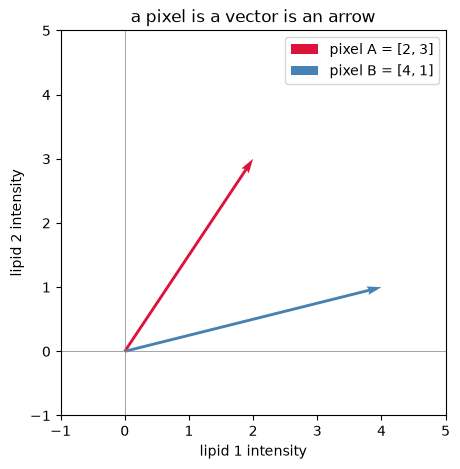

In [9]:
# Two pixels, each described by just 2 lipids, so we can actually draw them.
pixel_a = np.array([2.0, 3.0])   # high lipid-2, moderate lipid-1
pixel_b = np.array([4.0, 1.0])   # high lipid-1, low lipid-2

fig, ax = plt.subplots(figsize=(5, 5))
# Draw each vector as an arrow from the origin (0,0).
ax.quiver(0, 0, pixel_a[0], pixel_a[1], angles="xy", scale_units="xy",
          scale=1, color="crimson", label="pixel A = [2, 3]")
ax.quiver(0, 0, pixel_b[0], pixel_b[1], angles="xy", scale_units="xy",
          scale=1, color="steelblue", label="pixel B = [4, 1]")
ax.set_xlim(-1, 5); ax.set_ylim(-1, 5)
ax.axhline(0, color="grey", lw=0.5); ax.axvline(0, color="grey", lw=0.5)
ax.set_xlabel("lipid 1 intensity"); ax.set_ylabel("lipid 2 intensity")
ax.set_title("a pixel is a vector is an arrow")
ax.legend(); ax.set_aspect("equal")
plt.show()


**checkpoint**: you should see two arrows from the origin: a red one reaching up to (2, 3) and a blue one reaching right to (4, 1). Two pixels, two arrows, two dimensions. A real pixel is the same idea with hundreds of lipid dimensions instead of two.


## a matrix is a stack of vectors: our whole dataset

A **matrix** is a rectangle of numbers: rows and columns. Stack many pixel-vectors on top of each other and you have a matrix. This is *exactly* the shape of our data:

- each **row** is one pixel,
- each **column** is one lipid,
- the entry at row *i*, column *j* is the intensity of lipid *j* in pixel *i*.

A dataset of 300 pixels measured at 5 lipids is a 300-by-5 matrix. The course data is the same picture with more rows and more columns. This rows-are-samples, columns-are-features convention is the bedrock of every tool you will touch.


In [10]:
# A tiny 4-pixel by 2-lipid matrix, written by hand so you see the shape.
M = np.array([
    [2.0, 3.0],   # pixel 0
    [4.0, 1.0],   # pixel 1
    [1.0, 5.0],   # pixel 2
    [3.0, 3.0],   # pixel 3
])
print("the matrix:\n", M)
print("shape (rows, cols) = (pixels, lipids):", M.shape)


the matrix:
 [[2. 3.]
 [4. 1.]
 [1. 5.]
 [3. 3.]]
shape (rows, cols) = (pixels, lipids): (4, 2)


## the dot product: how aligned are two vectors?

The **dot product** of two vectors multiplies them entry by entry and sums the results. For `a = [2, 3]` and `b = [4, 1]`: `2*4 + 3*1 = 8 + 3 = 11`. One number falls out.

Why care? Geometrically the dot product measures **alignment**. Two arrows pointing the same way give a large positive number; perpendicular arrows give zero; opposite arrows give a negative number. "Projecting" the data onto a chosen direction, a move that runs quietly under many methods, literally means taking a dot product with that direction. Hold that thought; notebook 02 builds the geometry of projection out in full.

A **matrix multiply** is just many dot products bundled together: every row dotted with every column. That single operation is how a whole dataset gets transformed at once, the workhorse arithmetic under almost every tool you will touch.


In [11]:
# The dot product, three equivalent ways, all giving the same number.
a = np.array([2.0, 3.0])
b = np.array([4.0, 1.0])

print("by hand:      ", 2*4 + 3*1)
print("np.dot:       ", np.dot(a, b))
print("@ operator:   ", a @ b)   # @ is Python's matrix-multiply / dot operator


by hand:       11
np.dot:        11.0
@ operator:    11.0


❓ **QUESTION**: compute the dot product of `[1, 0]` and `[0, 1]` in your head. You get 0, because those arrows are perpendicular: one points purely along the first axis, the other purely along the second, so they share no alignment. Zero dot product means "at right angles", the property that lets us build independent axes, which notebook 02 puts to work.


---
# part 3 · numpy, the array engine

A Python list can hold anything, which makes it flexible but slow for math. **numpy** gives us the **array**: a grid of numbers, all the same type, with fast vectorised math. Every scientific library, pandas and scanpy included, is numpy underneath. This is VanderPlas chapter 2.


## generating our toy pixels-by-lipids table

Time to build the dataset we use for the rest of the notebook. It is synthetic but shaped like the real thing: a few hundred pixels, five lipid columns, plus the spatial coordinates `x, y` and a `condition` label (control versus pregnant), the same structure as a MALDI imaging section.

Read the code: we are not doing anything you have not met. We make random numbers with our seeded `RNG`, stack them into an array, and nudge the "pregnant" pixels to have a bit more of two lipids so there is real signal to find later.


In [12]:
# --- build a synthetic pixels-by-lipids dataset ---------------------------
n_pixels = 300
lipid_names = ["PC 34:1", "PE 38:4", "SM 36:1", "PS 40:6", "PI 38:4"]
n_lipids = len(lipid_names)

# Half the pixels are "control", half "pregnant".
condition = np.array(["control"] * 150 + ["pregnant"] * 150)

# Baseline intensities: positive numbers (lipid intensities are never negative).
# rng.gamma gives skewed, non-negative values, which is realistic for intensities.
X = RNG.gamma(shape=2.0, scale=1.0, size=(n_pixels, n_lipids))

# Inject biology: in pregnant pixels, raise SM 36:1 (index 2) and PS 40:6 (index 3).
is_preg = condition == "pregnant"
X[is_preg, 2] += 2.5    # more SM 36:1 when pregnant
X[is_preg, 3] += 1.5    # more PS 40:6 when pregnant

# Spatial coordinates: pretend the 300 pixels tile a 20x15 grid (20*15 = 300).
xs, ys = np.meshgrid(np.arange(20), np.arange(15))
x_coord = xs.flatten()
y_coord = ys.flatten()

print("X shape (pixels, lipids):", X.shape)
print("first pixel's 5 lipid intensities:\n", X[0])


X shape (pixels, lipids): (300, 5)
first pixel's 5 lipid intensities:
 [1.83431007 2.63769797 1.06635807 3.98054168 0.91323087]


## shape, indexing, and slicing arrays

`.shape` is the most-used attribute in scientific Python: it tells you the dimensions of the array as `(rows, columns)`. Indexing a 2D array uses `[row, column]`. A colon `:` means "all of this axis".


In [13]:
print("shape:", X.shape)            # (300, 5)

print("\none pixel, all lipids  X[0, :] :\n", X[0, :])
print("\none lipid, all pixels  X[:, 2]  (first 5 shown):\n", X[:5, 2])
print("\na 3-pixel by 2-lipid block  X[:3, :2] :\n", X[:3, :2])

shape: (300, 5)

one pixel, all lipids  X[0, :] :
 [1.83431007 2.63769797 1.06635807 3.98054168 0.91323087]

one lipid, all pixels  X[:, 2]  (first 5 shown):
 [1.06635807 0.52014926 3.12628474 1.95943368 2.03192028]

a 3-pixel by 2-lipid block  X[:3, :2] :
 [[1.83431007 2.63769797]
 [0.98456691 0.10641058]
 [1.50617526 0.94695449]]


## vectorised math: no loops needed

Here is numpy's superpower. To double every intensity, you do *not* write a loop. You write `X * 2` and numpy applies it to all 1500 numbers at once, in fast compiled code. This is "vectorised" math: operate on whole arrays as if they were single numbers.


In [14]:
# Whole-array math, no loop in sight.
print("original first pixel:", X[0])
print("doubled  first pixel:", (X * 2)[0])
print("log1p    first pixel:", np.log1p(X[0]))  # log(1+x), a common intensity transform

# Element-wise: adding two arrays adds them position by position.
print("\nX + X equals X * 2 everywhere?", np.allclose(X + X, X * 2))


original first pixel: [1.83431007 2.63769797 1.06635807 3.98054168 0.91323087]
doubled  first pixel: [3.66862013 5.27539595 2.13271615 7.96108337 1.82646173]
log1p    first pixel: [1.04179855 1.29135106 0.72578767 1.60553866 0.64879337]

X + X equals X * 2 everywhere? True


## the axis argument: which way do I summarise?

`.mean()`, `.sum()`, `.std()` can collapse an array. The `axis` argument says *which direction* to collapse.

- `axis=0` collapses **down the rows**, giving one number **per column** (per lipid): the mean intensity of each lipid across all pixels.
- `axis=1` collapses **across the columns**, giving one number **per row** (per pixel): the total or mean signal in each pixel.

The rule of thumb: `axis` is the dimension that *disappears*. `axis=0` removes the pixel dimension and leaves you with 5 lipid means.


In [15]:
# Mean intensity of each lipid (collapse the 300 pixels -> 5 numbers).
mean_per_lipid = X.mean(axis=0)
print("mean per lipid (axis=0), shape", mean_per_lipid.shape, ":\n", mean_per_lipid.round(2))

# Total intensity in each pixel (collapse the 5 lipids -> 300 numbers).
total_per_pixel = X.sum(axis=1)
print("\ntotal per pixel (axis=1), shape", total_per_pixel.shape)
print("first 5 pixel totals:", total_per_pixel[:5].round(2))


mean per lipid (axis=0), shape (5,) :
 [1.92 1.92 3.31 2.75 2.08]

total per pixel (axis=1), shape (300,)
first 5 pixel totals: [10.43  4.93  7.6   7.96 16.21]


## boolean masks: selecting by a condition

Compare an array to a number and numpy returns an array of `True`/`False`, one per element. That is a **boolean mask**. Feed the mask back in as an index and you keep only the `True` rows. This is how you say "give me only the pregnant pixels" without a loop.


In [16]:
# A mask is just an array of True/False.
preg_mask = condition == "pregnant"
print("mask (first 5):", preg_mask[:5])
print("how many True:", preg_mask.sum())   # True counts as 1, so sum = count

# Use the mask to pull out only pregnant pixels' SM 36:1 (lipid index 2).
sm_in_pregnant = X[preg_mask, 2]
sm_in_control  = X[~preg_mask, 2]          # ~ flips the mask (NOT pregnant)

print("\nmean SM 36:1 in pregnant:", sm_in_pregnant.mean().round(2))
print("mean SM 36:1 in control :", sm_in_control.mean().round(2))


mask (first 5): [False False False False False]
how many True: 150

mean SM 36:1 in pregnant: 4.7
mean SM 36:1 in control : 1.91


**checkpoint**: because the seed is fixed, the numbers are exact: mean SM 36:1 is `4.7` in pregnant and `1.91` in control. The pregnant value is more than double, exactly because we injected `+2.5` into pregnant pixels when we built the data. Seeing the signal we planted come back to the decimal confirms the mask selected the right rows. This control-versus-pregnant comparison is the toy version of the differential testing you will do for real.

---
# part 4 · pandas, tables with names

A numpy array is fast but anonymous: column 2 is just "2". **pandas** wraps an array in a **DataFrame** that has named columns and a row index, so you can write `df["SM 36:1"]` instead of `X[:, 2]`. DataFrames are how you handle the metadata: condition, coordinates, sample IDs. This is VanderPlas chapter 3.


## building a DataFrame and looking at it

We pour the numpy array into a DataFrame, name the columns after the lipids, then bolt on the metadata columns `condition`, `x`, `y`.


In [17]:
# Build a DataFrame: the lipid matrix plus metadata columns.
df = pd.DataFrame(X, columns=lipid_names)
df["condition"] = condition
df["x"] = x_coord
df["y"] = y_coord

# .head() shows the first 5 rows, your first reflex with any new table.
df.head()


,PC 34:1,PE 38:4,SM 36:1,PS 40:6,PI 38:4,condition,x,y
0,1.834310,2.637698,1.066358,3.980542,0.913231,control,0,0
1,0.984567,0.106411,0.520149,1.058145,2.256560,control,1,0
2,1.506175,0.946954,3.126285,0.879286,1.142832,control,2,0
3,0.673507,1.469443,1.959434,0.957056,2.897471,control,3,0
4,0.512375,4.077918,2.031920,4.346492,5.242299,control,4,0


`.head()` shows the top rows; `.shape` gives `(rows, columns)`; `.columns` lists the column names; `.describe()` summarises each numeric column. Use these four to orient yourself in any table you meet.


In [18]:
print("shape (rows, cols):", df.shape)
print("columns:", list(df.columns))
df.describe().round(2)     # count, mean, std, min, quartiles, max per column


shape (rows, cols): (300, 8)
columns: ['PC 34:1', 'PE 38:4', 'SM 36:1', 'PS 40:6', 'PI 38:4', 'condition', 'x', 'y']


,PC 34:1,PE 38:4,SM 36:1,PS 40:6,PI 38:4,x,y
count,300.00,300.00,300.00,300.00,300.00,300.00,300.00
mean,1.92,1.92,3.31,2.75,2.08,9.50,7.00
std,1.43,1.42,2.01,1.58,1.38,5.78,4.33
min,0.03,0.11,0.02,0.11,0.17,0.00,0.00
25%,0.88,0.93,1.78,1.62,1.04,4.75,3.00
50%,1.54,1.50,3.22,2.52,1.80,9.50,7.00
75%,2.49,2.62,4.37,3.63,2.83,14.25,11.00
max,8.81,8.06,10.62,8.88,8.51,19.00,14.00


## value_counts: how many of each category?

`.value_counts()` tallies how often each value appears in a column. It is the fastest way to answer "how many pixels per condition?".


In [19]:
# Count pixels per condition.
df["condition"].value_counts()


condition
control     150
pregnant    150
Name: count, dtype: int64

## groupby: split, compute, combine

`groupby` is the workhorse of data analysis. You **split** the table into groups (one per condition), **compute** something on each group (the mean of each lipid), and pandas **combines** the answers into a tidy table. This one line replaces an entire for-loop with a mask per group.


In [20]:
# Mean of every lipid, separately for control and pregnant pixels.
group_means = df.groupby("condition")[lipid_names].mean()
group_means.round(2)


,PC 34:1,PE 38:4,SM 36:1,PS 40:6,PI 38:4
condition,,,,,
control,2.04,1.89,1.91,1.99,2.05
pregnant,1.80,1.94,4.70,3.52,2.12


Look at the `SM 36:1` and `PS 40:6` columns: the pregnant row is visibly higher, exactly the two lipids we boosted. groupby just recovered our planted biology in one line. This is the manual-then-the-library-does-it-for-you idea: you computed one group mean by hand with a numpy mask above, and now pandas does *all* of them at once.


🔬 **TASK**: compute the mean of every lipid grouped by condition, but using the **median** instead of the mean. The pattern is identical; just swap the final method. Fill in the blank.


In [21]:
# Swap .mean() for .median() to get medians per group.
group_medians = df.groupby("condition")[lipid_names].median()
group_medians.round(2)


,PC 34:1,PE 38:4,SM 36:1,PS 40:6,PI 38:4
condition,,,,,
control,1.75,1.53,1.78,1.63,1.77
pregnant,1.41,1.48,4.26,3.24,1.80


## boolean filtering and adding columns

The same boolean-mask idea from numpy works on DataFrames, and reads almost like English. You can also create new columns by assigning to a name that does not exist yet.


In [22]:
# FILTER: keep only pregnant pixels. The mask goes inside df[...].
preg_rows = df[df["condition"] == "pregnant"]
print("pregnant pixels:", preg_rows.shape[0])

# ADD A COLUMN: total lipid signal per pixel (sum across the 5 lipid columns).
df["total_signal"] = df[lipid_names].sum(axis=1)

# Combine: pregnant pixels whose total signal is above the overall median.
threshold = df["total_signal"].median()
bright_preg = df[(df["condition"] == "pregnant") & (df["total_signal"] > threshold)]
print("bright pregnant pixels:", bright_preg.shape[0])

df[["condition", "SM 36:1", "total_signal"]].head()


pregnant pixels: 150
bright pregnant pixels: 110


,condition,SM 36:1,total_signal
0,control,1.066358,10.432139
1,control,0.520149,4.925832
2,control,3.126285,7.601532
3,control,1.959434,7.956911
4,control,2.031920,16.211004


🔬 **TASK**: filter the table to keep only **control** pixels whose `PS 40:6` value is above 3.0, and print how many there are. Fill in the two blanks below. (Note the `&` for "and" and the parentheses around each condition; pandas needs both.)


In [23]:
# Condition equals "control" AND PS 40:6 above 3.0.
subset = df[(df["condition"] == "control") & (df["PS 40:6"] > 3.0)]
print("matching control pixels:", subset.shape[0])


matching control pixels: 28


---
# part 5 · matplotlib, seeing the data

Plots are not decoration in this course; they are how we *think*. Every step of the real pipeline is checked by looking at a figure. matplotlib is the foundation every other plotting library sits on, so we learn it first. This is VanderPlas chapter 4.


## the figure-versus-axes mental model

This is the one idea that makes matplotlib click. A **figure** is the whole canvas, the sheet of paper. An **axes** (confusingly singular, "an axes") is one plot *on* that canvas: it has its own x-axis, y-axis, title. One figure can hold many axes arranged in a grid.

You almost always start with `fig, ax = plt.subplots()`, which hands you the figure and one axes. Then you call methods on `ax`: `ax.hist(...)`, `ax.scatter(...)`, `ax.set_xlabel(...)`. Reading code, whenever you see `ax.` you know "this draws on one panel".


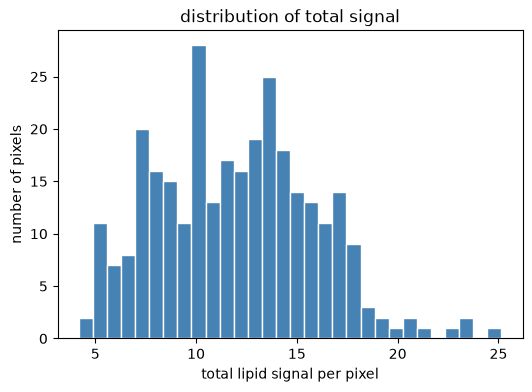

In [24]:
# One figure, one axes: a histogram of total signal per pixel.
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df["total_signal"], bins=30, color="steelblue", edgecolor="white")
ax.set_xlabel("total lipid signal per pixel")
ax.set_ylabel("number of pixels")
ax.set_title("distribution of total signal")
plt.show()


A **histogram** bins values and counts how many fall in each bin: it shows the *shape* of one variable's distribution. Always label both axes; an unlabelled plot is a riddle.


## many axes on one figure: subplots

Ask `plt.subplots(rows, cols)` for a grid and you get an array of axes. Loop over them to fill each panel. Here we draw the histogram of one lipid for each condition side by side, the canonical "compare groups" view.


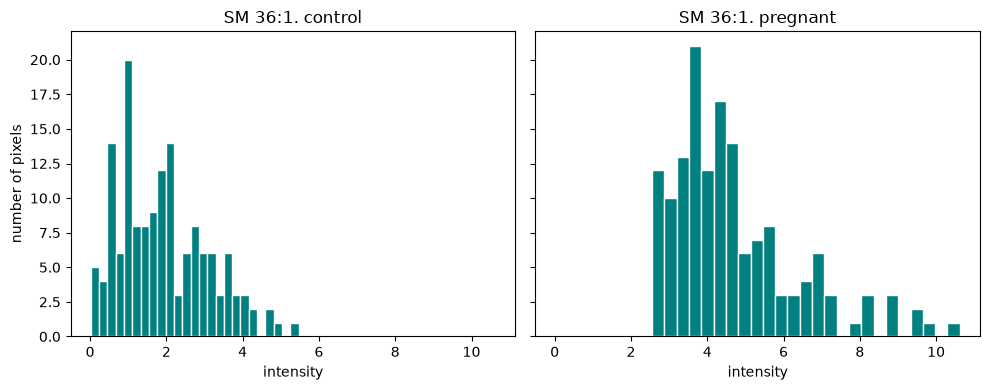

In [25]:
# Two panels side by side: SM 36:1 in control vs pregnant.
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

for ax, cond in zip(axes, ["control", "pregnant"]):
    values = df.loc[df["condition"] == cond, "SM 36:1"]
    ax.hist(values, bins=25, color="teal", edgecolor="white")
    ax.set_title(f"SM 36:1. {cond}")
    ax.set_xlabel("intensity")
axes[0].set_ylabel("number of pixels")
plt.tight_layout()   # stop the labels overlapping
plt.show()


❓ **QUESTION**: the pregnant histogram sits noticeably to the right of the control one. What does "shifted right" mean biologically here? (It means pregnant pixels tend to have *higher* SM 36:1 intensity. A rightward shift in the whole distribution is exactly the signal a statistical test will later try to call significant or not.)


## scatter plots: two variables at once, and a spatial map

A **scatter** plots one variable against another, one dot per pixel. Because our pixels have real `x, y` coordinates, a scatter of `x` versus `y`, coloured by a lipid's intensity, *is* a tissue image. This is the heart of spatial metabolomics: the colour at each spot tells you how much of a lipid sits there.


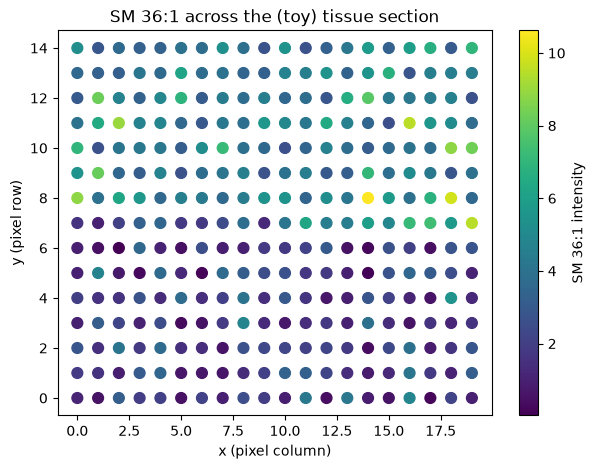

In [26]:
# Spatial map: each pixel placed at (x, y), coloured by SM 36:1 intensity.
fig, ax = plt.subplots(figsize=(7, 5))
points = ax.scatter(df["x"], df["y"], c=df["SM 36:1"],
                    cmap="viridis", s=60)
ax.set_xlabel("x (pixel column)")
ax.set_ylabel("y (pixel row)")
ax.set_title("SM 36:1 across the (toy) tissue section")
fig.colorbar(points, ax=ax, label="SM 36:1 intensity")
plt.show()


Our toy coordinates are random with respect to condition, so this map looks like noise. That is fine and honest: real tissue would show structure (a bright myelin-rich region, say), but the *mechanics* of "place pixels by x,y and colour by a lipid" are exactly what you just ran. The real data only changes the picture, not the code.


🔬 **TASK**: make a scatter of `PS 40:6` (x-axis) against `SM 36:1` (y-axis), one dot per pixel, coloured by condition. Two lipids that both rise in pregnancy should show pregnant pixels drifting to the upper right. Fill in the blanks.


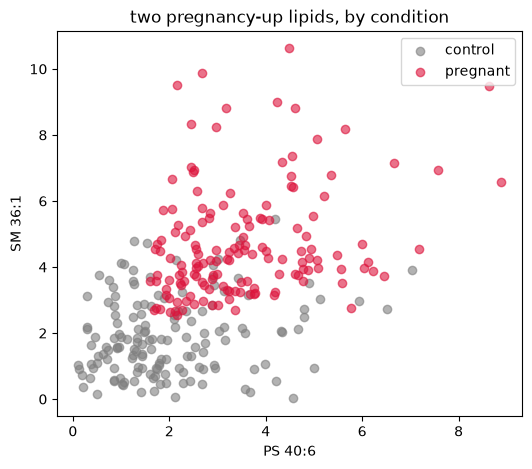

In [27]:
# Colour-code the two conditions and overlay them on one axes.
fig, ax = plt.subplots(figsize=(6, 5))
for cond, colour in [("control", "grey"), ("pregnant", "crimson")]:
    sub = df[df["condition"] == cond]
    ax.scatter(sub["PS 40:6"], sub["SM 36:1"], label=cond, color=colour, alpha=0.6)
ax.set_xlabel("PS 40:6"); ax.set_ylabel("SM 36:1")
ax.set_title("two pregnancy-up lipids, by condition")
ax.legend()
plt.show()


## seaborn and scanpy are numpy + matplotlib underneath

**seaborn** is a thin, pretty layer over matplotlib for statistical plots. **scanpy** (and the spatial tools you will use) wrap matplotlib for omics-specific plots. They save typing, but every one of them returns matplotlib axes you can keep customising. Knowing this means you are never stuck: when a wrapper does not give the exact figure a paper needs, you drop down to `ax.` and finish it by hand.


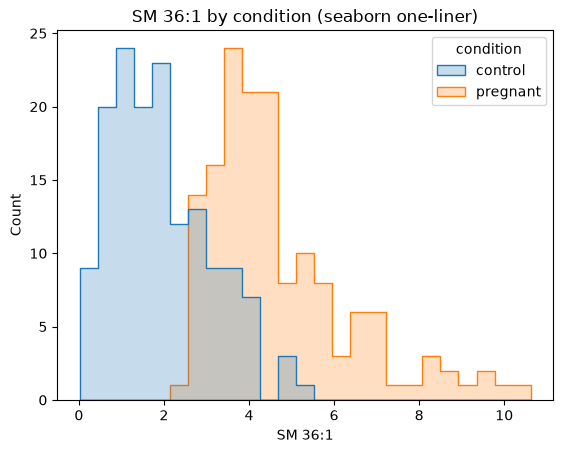

In [28]:
# The SAME comparison as before, in ONE seaborn line. Under the hood this is
# building the same histograms on a matplotlib axes we could still tweak.
sns.histplot(data=df, x="SM 36:1", hue="condition", bins=25, element="step")
plt.title("SM 36:1 by condition (seaborn one-liner)")
plt.show()


> A working rule from the course style: use the one-liner to look fast, but when you build the *publication* figure, expect to drop to raw matplotlib for full control. AI assistants are excellent at drafting plotting code from a plain-English description, but if you cannot read the code they hand back, stop and look the functions up. The goal is understanding, not just a picture.


---
# part 6 · AnnData, the smart container

So far the lipid matrix `X`, the metadata `df`, and the lipid names live in separate variables. That gets fragile fast. The whole single-cell and spatial-omics world stores everything in one object instead: **AnnData**. 

Think of AnnData as a smart container built around one central matrix, with synchronised side-tables that always stay aligned to it:

| slot | holds | in our data |
|------|-------|-------------|
| `adata.X` | the main matrix, rows × columns | **pixels × lipids** intensities |
| `adata.obs` | per-row metadata (a DataFrame) | **per-pixel**: condition, x, y |
| `adata.var` | per-column metadata (a DataFrame) | **per-lipid**: name, m/z |
| `adata.obsm` | per-row multi-column arrays | **embeddings**: low-dimensional coordinates |
| `adata.uns` | unstructured extras | settings, colour palettes, results |

If you have ever seen scanpy used on single-cell RNA-seq, this is the *same object*, just relabelled: there `X` is cells × genes, here it is pixels × lipids. The mental model transfers one-to-one. `obs` = "observations" = the rows; `var` = "variables" = the columns.


In [29]:
import anndata as ad

# AnnData wants STRING names for its rows and columns (obs_names, var_names),
# not bare integers. So we give obs an explicit string index: "pixel_0",
# "pixel_1", ... If we skipped this, AnnData would quietly turn our integer
# row numbers into strings for us and print a yellow ImplicitModificationWarning
# saying so. Naming them ourselves is tidier and keeps the output clean.
pixel_ids = [f"pixel_{i}" for i in range(n_pixels)]

# obs: one row per pixel, holding the metadata (must line up with X's rows).
obs = pd.DataFrame({
    "condition": condition,
    "x": x_coord,
    "y": y_coord,
}, index=pixel_ids)
# var: one row per lipid, holding per-lipid info (must line up with X's columns).
# Its index is already strings (the lipid names), so var needs nothing extra.
var = pd.DataFrame(
    {"mz": [760.585, 768.554, 731.606, 834.529, 885.550]},
    index=lipid_names,
)

# Assemble the container. X is the pixels-by-lipids matrix from before.
adata = ad.AnnData(X=X, obs=obs, var=var)
adata

AnnData object with n_obs × n_vars = 300 × 5
    obs: 'condition', 'x', 'y'
    var: 'mz'

The printed summary reads `n_obs × n_vars = 300 × 5`, with `obs:` listing the per-pixel columns and `var:` the per-lipid columns. One object now carries the whole dataset, guaranteed aligned: row 7 of `X`, row 7 of `obs`, and the pixel at `obs.x[7], obs.y[7]` are the same pixel, always.


In [30]:
# Reach into the slots, exactly as the real notebooks do.
print("shape (pixels, lipids):", adata.shape)
print("\nper-pixel metadata, adata.obs.head():")
print(adata.obs.head())
print("\nper-lipid metadata, adata.var:")
print(adata.var)
print("\nthe lipid names (var_names):", list(adata.var_names))


shape (pixels, lipids): (300, 5)

per-pixel metadata, adata.obs.head():
        condition  x  y
pixel_0   control  0  0
pixel_1   control  1  0
pixel_2   control  2  0
pixel_3   control  3  0
pixel_4   control  4  0

per-lipid metadata, adata.var:
              mz
PC 34:1  760.585
PE 38:4  768.554
SM 36:1  731.606
PS 40:6  834.529
PI 38:4  885.550

the lipid names (var_names): ['PC 34:1', 'PE 38:4', 'SM 36:1', 'PS 40:6', 'PI 38:4']


🔬 **TASK**: use `value_counts` on the AnnData object's per-pixel metadata to count pixels per condition (you did this on the plain DataFrame earlier; the syntax is identical because `adata.obs` *is* a DataFrame). Fill in the blanks.


In [31]:
# adata.obs is a DataFrame. Count pixels per condition.
adata.obs["condition"].value_counts()


condition
control     150
pregnant    150
Name: count, dtype: int64

---
# checkpoint

- **Python**: variables, lists, dicts, loops, functions, indexing, and the reflex to read the docs before guessing.
- **linear algebra**: a pixel is a vector, the dataset is a matrix, a dot product measures alignment, and projecting onto a direction is just a dot product.
- **numpy**: arrays, `.shape`, `axis=0` versus `axis=1`, vectorised math, boolean masks.
- **pandas**: DataFrames, `.head()`, `value_counts`, `groupby`, boolean filtering, adding columns.
- **matplotlib**: figure versus axes, histograms, scatters, spatial maps, and that seaborn and scanpy are matplotlib underneath.
- **AnnData**: `.X` pixels × lipids, `.obs` per pixel, `.var` per lipid, `.obsm` embeddings.

**next** → notebook **02, the maths and statistics you will lean on**, a deeper revision of the linear algebra you just sampled (vectors, matrices, projections, eigenvectors) together with the probability and statistics the course leans on (distributions, correlation, regression, hypothesis testing and the t-test). 

For deeper practice on anything above, the one book to keep open is VanderPlas, *Python Data Science Handbook*, free at [jakevdp.github.io/PythonDataScienceHandbook](https://jakevdp.github.io/PythonDataScienceHandbook/).
